In [2]:
import pandas as pd
from helpers import *

In [3]:
medical = pd.read_csv("동물약국 시군별 수(06-11 수정됨).csv", encoding="cp949")
funeral = pd.read_csv("동물장례식장 시군별 수(06-11 수정됨).csv", encoding="cp949")
shelter = pd.read_csv("동물보호센터 시군별 수(06-11 수정됨).csv", encoding="cp949")
pet_hospital = pd.read_csv("시군별_동물병원_동물수.csv")

In [4]:
shelter.head()

,시_주소,정상
0,가평군,1
1,고양시,1
2,광명시,1
3,광주시,2
4,구리시,1


In [5]:
pet_hospital = pet_hospital.rename(columns={'시군' : '시_주소'})
pet_hospital = pet_hospital.drop(columns=['시군구'])
pet_hospital.head()

,시_주소,동물병원수,개등록 누계,고양이등록 누계,총 등록 누계,병원당_동물수
0,고양시,123,73953,799,74752,607.739837
1,용인시,122,66533,812,67345,552.008197
2,수원시,121,75009,766,75775,626.239669
3,성남시,117,59674,793,60467,516.811966
4,화성시,96,49820,468,50288,523.833333


In [6]:
medical2 = medical[['시_주소', '정상']]
medical2 = medical2.rename(columns={'정상' : '약국 수'})
medical2.head()

,시_주소,약국 수
0,가평군,11.0
1,고양시,337.0
2,과천시,17.0
3,광명시,89.0
4,광주시,99.0


In [7]:
shelter2 = shelter.rename(columns={'정상' : '보호소 수'})
shelter2.head()

,시_주소,보호소 수
0,가평군,1
1,고양시,1
2,광명시,1
3,광주시,2
4,구리시,1


In [8]:
funeral2 = funeral[['시_주소', '정상']]
funeral2 = funeral2.rename(columns={'정상' : '장례식장 수'})
funeral2.head()

,시_주소,장례식장 수
0,고양시,1.0
1,광주시,7.0
2,구리시,0.0
3,김포시,3.0
4,남양주시,3.0


In [9]:
# 병원에 존재하지 않는 주소가 약국 데이터에 존재할 수도 있으므로 outer로 변경하였습니다. 아래 데이터들도 모두 동일한 전제하에 outer로 변경하였습니다.
result = pet_hospital.merge(
    medical2,
    on='시_주소',
    how='outer'
)

result = result.merge(
    funeral2,
    on='시_주소',
    how='outer'
)

result = result.merge(
    shelter2,
    on='시_주소',
    how='outer'
)

result.head()

,시_주소,동물병원수,개등록 누계,고양이등록 누계,총 등록 누계,병원당_동물수,약국 수,장례식장 수,보호소 수
0,가평군,9,6324,37,6361,706.777778,11.0,NaN,1.0
1,고양시,123,73953,799,74752,607.739837,337.0,1.0,1.0
2,과천시,14,2894,47,2941,210.071429,17.0,NaN,NaN
3,광명시,19,20973,118,21091,1110.052632,89.0,NaN,1.0
4,광주시,38,28452,400,28852,759.263158,99.0,7.0,2.0


In [10]:
# 결과가 기존에 올려주신거랑 다른데, 정렬해서 두 데이터 비교해보면 값은 동일합니다 순서만 바뀐거라 신경 안쓰셔도 될것 같습니다.
result2 = result[['시_주소', '총 등록 누계', '동물병원수', '병원당_동물수', '약국 수', '보호소 수', '장례식장 수']]
result2.head()

,시_주소,총 등록 누계,동물병원수,병원당_동물수,약국 수,보호소 수,장례식장 수
0,가평군,6361,9,706.777778,11.0,1.0,NaN
1,고양시,74752,123,607.739837,337.0,1.0,1.0
2,과천시,2941,14,210.071429,17.0,NaN,NaN
3,광명시,21091,19,1110.052632,89.0,1.0,NaN
4,광주시,28852,38,759.263158,99.0,2.0,7.0


In [11]:
result2 = result2.rename(columns={'총 등록 누계' : '등록동물 수', '병원당_동물수' : '병원당 동물 수'})
result2.head()

,시_주소,등록동물 수,동물병원수,병원당 동물 수,약국 수,보호소 수,장례식장 수
0,가평군,6361,9,706.777778,11.0,1.0,NaN
1,고양시,74752,123,607.739837,337.0,1.0,1.0
2,과천시,2941,14,210.071429,17.0,NaN,NaN
3,광명시,21091,19,1110.052632,89.0,1.0,NaN
4,광주시,28852,38,759.263158,99.0,2.0,7.0


In [12]:
# 해당 데이터셋 에선 Null 값은 없다는 것을 의미하므로 0으로 채움
result2 = result2.fillna(0)
result2.head()

,시_주소,등록동물 수,동물병원수,병원당 동물 수,약국 수,보호소 수,장례식장 수
0,가평군,6361,9,706.777778,11.0,1.0,0.0
1,고양시,74752,123,607.739837,337.0,1.0,1.0
2,과천시,2941,14,210.071429,17.0,0.0,0.0
3,광명시,21091,19,1110.052632,89.0,1.0,0.0
4,광주시,28852,38,759.263158,99.0,2.0,7.0


In [13]:
result3 = result2.copy()

result3.loc[result3['보호소 수'] > 0,'보호소_유무']= "존재함"
result3.loc[result3['보호소 수'] == 0,'보호소_유무']= "존재하지않음"
result3.loc[result3['장례식장 수'] > 0,'장례식장_유무']= "존재함"
result3.loc[result3['장례식장 수'] == 0,'장례식장_유무']= "존재하지않음"

result3['시_주소'] = result3['시_주소'].astype('category')
result3['보호소_유무'] = result3['보호소_유무'].astype('category')
result3['장례식장_유무'] = result3['장례식장_유무'].astype('category')
result3.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   시_주소      31 non-null     category
 1   등록동물 수    31 non-null     int64   
 2   동물병원수     31 non-null     int64   
 3   병원당 동물 수  31 non-null     float64 
 4   약국 수      31 non-null     float64 
 5   보호소 수     31 non-null     float64 
 6   장례식장 수    31 non-null     float64 
 7   보호소_유무    31 non-null     category
 8   장례식장_유무   31 non-null     category
dtypes: category(3), float64(4), int64(2)
memory usage: 2.3 KB


In [14]:
result3 = result3.drop(columns=['보호소 수','장례식장 수'])
result3.head()

,시_주소,등록동물 수,동물병원수,병원당 동물 수,약국 수,보호소_유무,장례식장_유무
0,가평군,6361,9,706.777778,11.0,존재함,존재하지않음
1,고양시,74752,123,607.739837,337.0,존재함,존재함
2,과천시,2941,14,210.071429,17.0,존재하지않음,존재하지않음
3,광명시,21091,19,1110.052632,89.0,존재함,존재하지않음
4,광주시,28852,38,759.263158,99.0,존재함,존재함


In [15]:
my_qtcheck.numerical_summary(result3).T

,등록동물 수,동물병원수,병원당 동물 수,약국 수
count,31.0,31.0,31.0,31.0
mean,29275.258065,45.096774,670.175106,123.193548
std,21884.135866,36.072478,231.720378,103.62896
min,2325.0,7.0,210.071429,10.0
25%,12807.5,17.5,537.920765,33.0
50%,21091.0,36.0,638.254237,99.0
75%,43239.0,56.0,763.866873,182.0
max,75775.0,123.0,1251.820513,348.0
rel_diff,0.388045,0.252688,0.050013,0.244379
rdiff_flag,diff,diff,similar,diff


# 결과


## 중심 수준 파악
- 해당 결과를 보면 약국, 보호센터, 장례식장은 모두 평균과 중앙값 간의 차이(약국 diff / 보호센터 diff / 장례식장 large_diff)가 존재한다.이는 분포의 편차가 존재한다도 봐야한다.

## 퍼짐과 안정성 판단
- 이상치에 대한 처리를 하지 않으므로 X

## 비대칭 신호 확인
- 모두 오른쪽 꼬리(약국의 왜도 > 0.5, 첨도 > 0 -> 우측 꼬리 분포 / 보호센터의 왜도 > 1.0 -> 강한 우측 꼬리 분포 / 장례식장 왜도 > 1.0 -> 강한 우측 꼬리 분포)를 갖는다. 즉, 약국, 보호센터, 장례식장의 개수 모두 시/군 중에 유독 많은 시/군이 존재(예:수원시, 고양시 등)한다고 볼 수 있다.

## 이상치 점검 결과
- 이상치에 대해선 처리 X

## 이상치 삭제 내역
- 이상치에 대해선 처리 X

## 기술 통계량 해석
- 정상_약국(운영중인 약국의 개수를 의미)
    - 1. 상대 편차가 0.24로 약간의 편차가 존재한다.
    - 2. 이상치는 0개로 

In [16]:
result2.describe()

,등록동물 수,동물병원수,병원당 동물 수,약국 수,보호소 수,장례식장 수
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,29275.258065,45.096774,670.175106,123.193548,0.774194,0.870968
std,21884.135866,36.072478,231.720378,103.628960,0.844972,1.543631
min,2325.000000,7.000000,210.071429,10.000000,0.000000,0.000000
25%,12807.500000,17.500000,537.920765,33.000000,0.000000,0.000000
50%,21091.000000,36.000000,638.254237,99.000000,1.000000,0.000000
75%,43239.000000,56.000000,763.866873,182.000000,1.000000,1.000000
max,75775.000000,123.000000,1251.820513,348.000000,4.000000,7.000000


In [17]:
my_qtcheck.numerical_summary(data=result2).T

,등록동물 수,동물병원수,병원당 동물 수,약국 수,보호소 수,장례식장 수
count,31.0,31.0,31.0,31.0,31.0,31.0
mean,29275.258065,45.096774,670.175106,123.193548,0.774194,0.870968
std,21884.135866,36.072478,231.720378,103.62896,0.844972,1.543631
min,2325.0,7.0,210.071429,10.0,0.0,0.0
25%,12807.5,17.5,537.920765,33.0,0.0,0.0
50%,21091.0,36.0,638.254237,99.0,1.0,0.0
75%,43239.0,56.0,763.866873,182.0,1.0,1.0
max,75775.0,123.0,1251.820513,348.0,4.0,7.0
rel_diff,0.388045,0.252688,0.050013,0.244379,0.225806,inf
rdiff_flag,diff,diff,similar,diff,diff,large_diff


# 결과

등록동물 수	동물병원수	병원당 동물 수	약국 수	보호소 수	장례식장 수

## 중심 수준 파악
- 등록동물 수의 상대 편차 수준이 0.388로 약간의 편차가 존재한다. 즉 분포에 편차가 존재한다.
- 동물병원 수의 상대 편차 수준이 0.253로 약간의 편차가 존재한다. 즉 분포에 편차가 존재한다.
- 

## 퍼짐과 안정성 판단
- 이상치에 대한 처리를 하지 않으므로 X

## 비대칭 신호 확인
- 모두 오른쪽 꼬리(약국의 왜도 > 0.5, 첨도 > 0 -> 우측 꼬리 분포 / 보호센터의 왜도 > 1.0 -> 강한 우측 꼬리 분포 / 장례식장 왜도 > 1.0 -> 강한 우측 꼬리 분포)를 갖는다. 즉, 약국, 보호센터, 장례식장의 개수 모두 시/군 중에 유독 많은 시/군이 존재(예:수원시, 고양시 등)한다고 볼 수 있다.

## 이상치 점검 결과
- 이상치에 대해선 처리 X

## 이상치 삭제 내역
- 이상치에 대해선 처리 X

## 기술 통계량 해석
- 정상_약국(운영중인 약국의 개수를 의미)
    - 1. 상대 편차가 0.24로 약간의 편차가 존재한다.
    - 2. 이상치는 0개로 

---------------------------------------------------------------------------------------------------------
등록동물 수와 인프라수가 양의 관계인지

등록동물 수의 사분위 수 Q1, Q2, Q3, Q4의 등록동물수 평균, 인프라 수 평균이 어떤지

In [18]:
result4 = result3.copy()
result4['인프라 수'] = result4['동물병원수']+result4['약국 수']
result4=result4[['시_주소', '등록동물 수', '인프라 수']]
result4.head()

,시_주소,등록동물 수,인프라 수
0,가평군,6361,20.0
1,고양시,74752,460.0
2,과천시,2941,31.0
3,광명시,21091,108.0
4,광주시,28852,137.0


In [19]:
# 등록동물 수, 인프라 수 기술통계량
my_qtcheck.numerical_summary(data=result4).T

,등록동물 수,인프라 수
count,31.0,31.0
mean,29275.258065,168.290323
std,21884.135866,138.119078
min,2325.0,17.0
25%,12807.5,58.5
50%,21091.0,137.0
75%,43239.0,228.0
max,75775.0,469.0
rel_diff,0.388045,0.228397
rdiff_flag,diff,diff


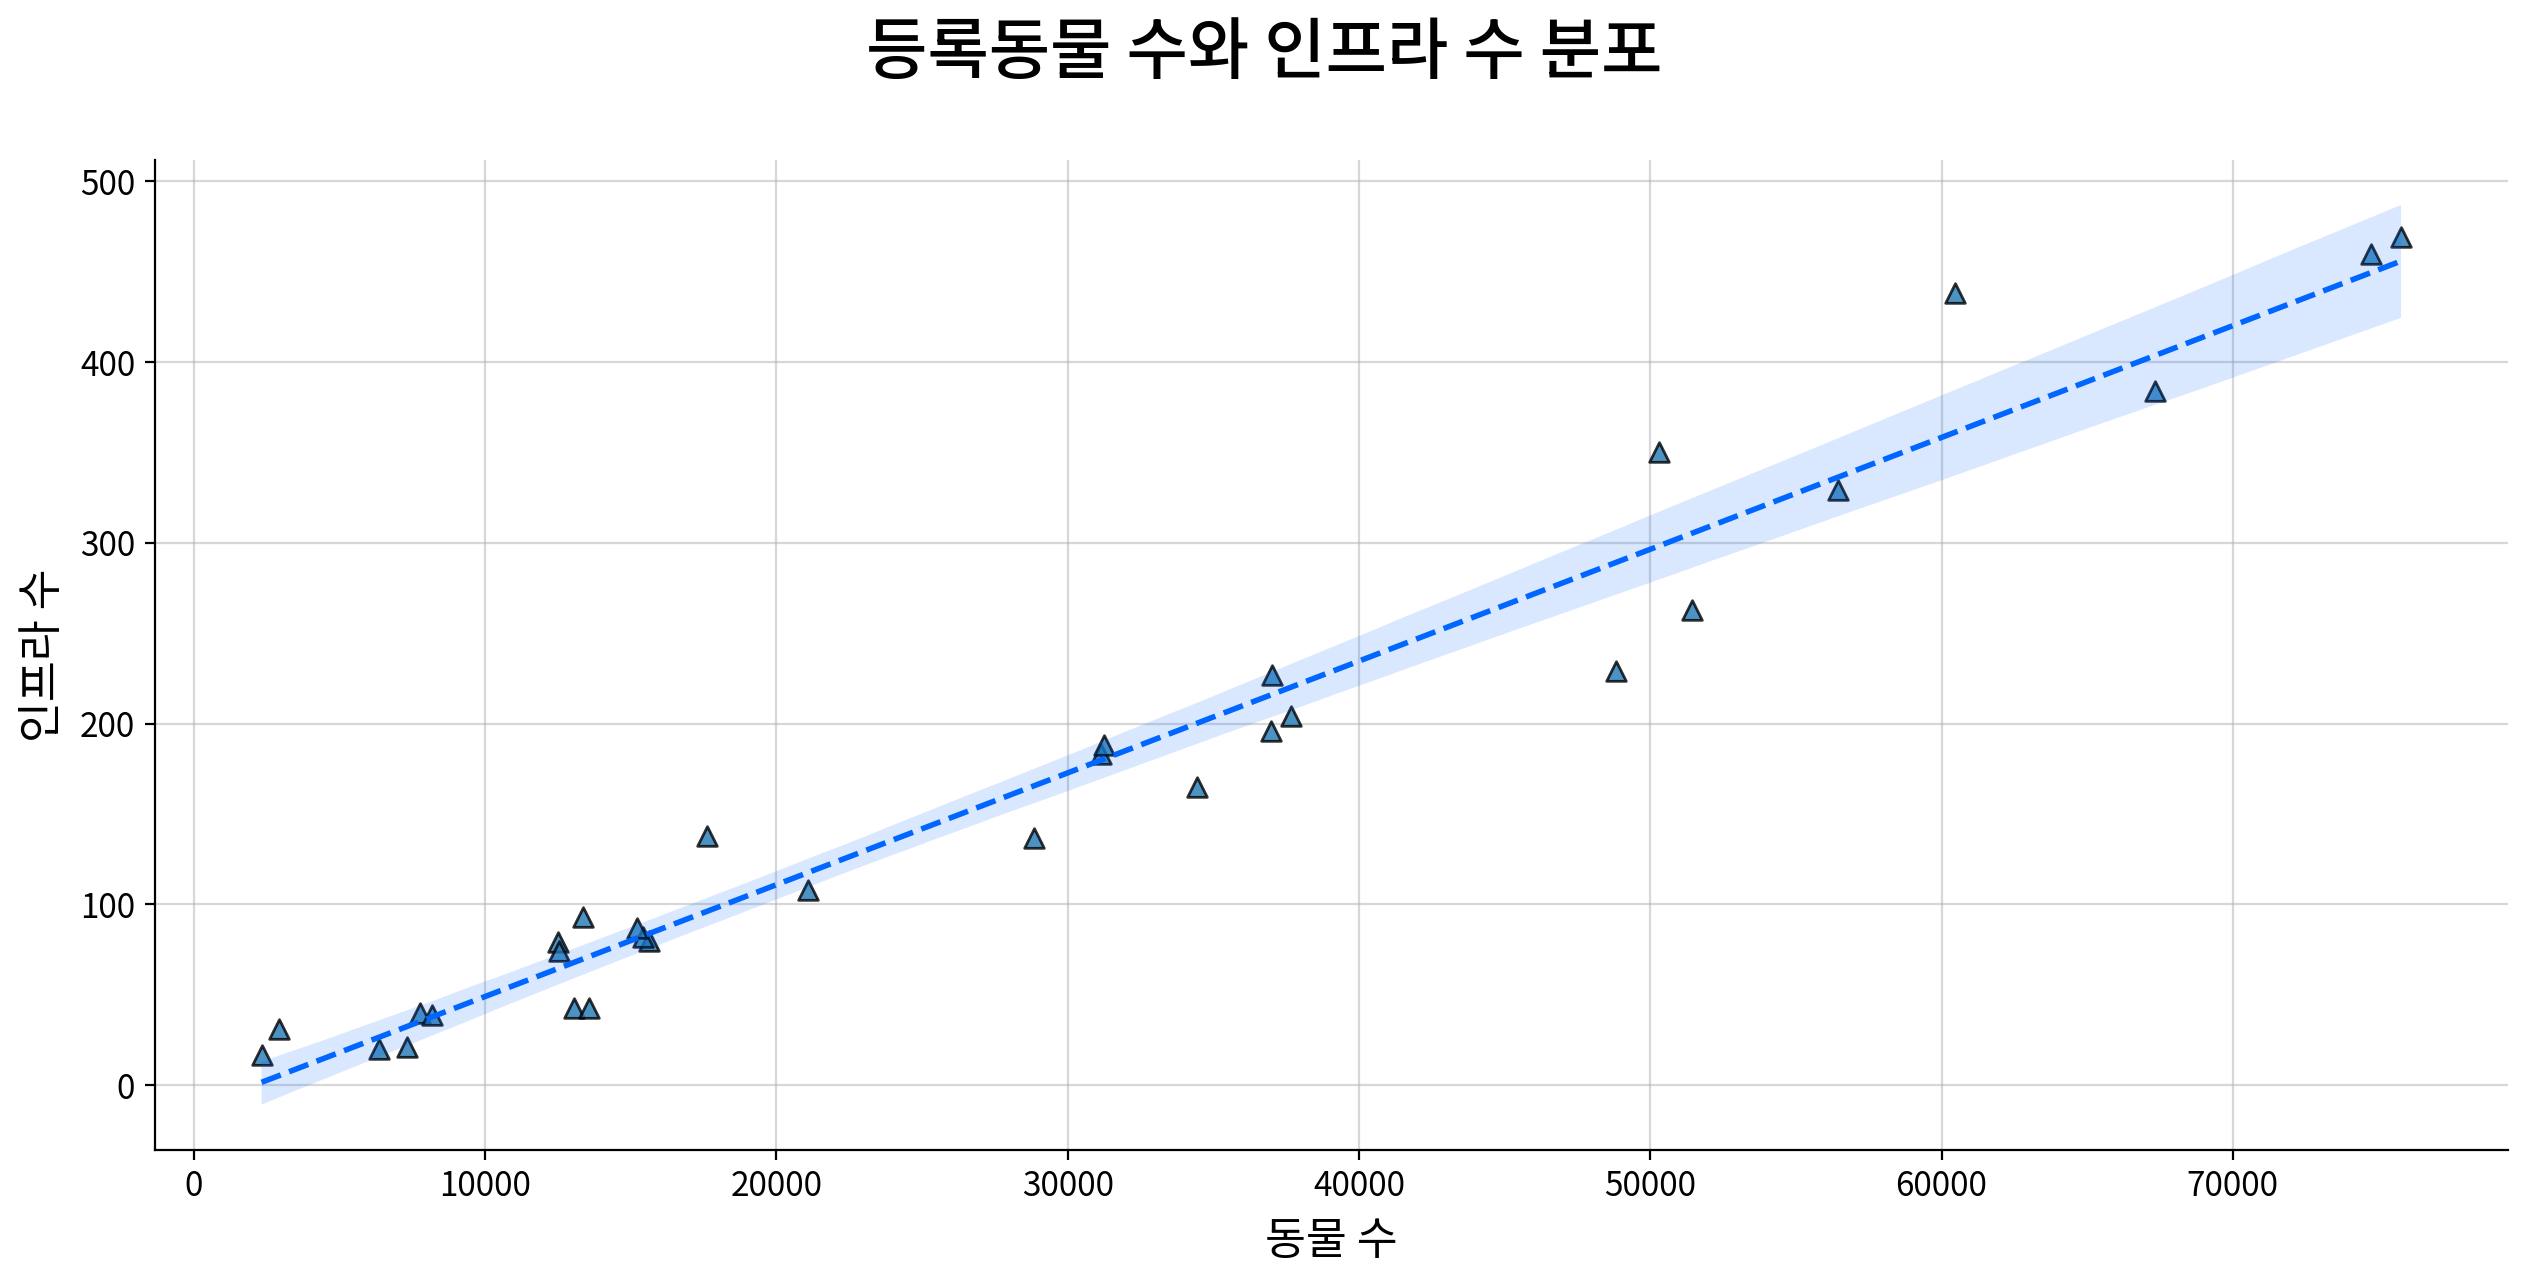

In [20]:
# 등록동물 수, 인프라 수 lmplot
my_plot.lmplot(data=result4, x="등록동물 수", y="인프라 수",
               title='등록동물 수와 인프라 수 분포',
               xlabel='동물 수', ylabel='인프라 수',
               markers="^",
               scatter_edgecolor="#000000", scatter_linewidths=1, scatter_size=50,
               linestyle="--", linecolor="#0066ff", linewidth=2)

In [21]:
# result5 = 동물/인프라 컬럼 추가
result5=result4.copy()
result5['동물/인프라'] = result4['등록동물 수']/result4['인프라 수']
result5

,시_주소,등록동물 수,인프라 수,동물/인프라
0,가평군,6361,20.0,318.050000
1,고양시,74752,460.0,162.504348
2,과천시,2941,31.0,94.870968
3,광명시,21091,108.0,195.287037
4,광주시,28852,137.0,210.598540
5,구리시,12489,79.0,158.088608
6,군포시,15610,80.0,195.125000
7,김포시,31128,183.0,170.098361
8,남양주시,51450,263.0,195.627376
9,동두천시,7324,21.0,348.761905


In [22]:
# 사분위수 컬럼 추가
result5['등록동물 수 사분위'] = pd.qcut(
    result5['등록동물 수'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4'])
result5.head()

,시_주소,등록동물 수,인프라 수,동물/인프라,등록동물 수 사분위
0,가평군,6361,20.0,318.050000,Q1
1,고양시,74752,460.0,162.504348,Q4
2,과천시,2941,31.0,94.870968,Q1
3,광명시,21091,108.0,195.287037,Q2
4,광주시,28852,137.0,210.598540,Q3


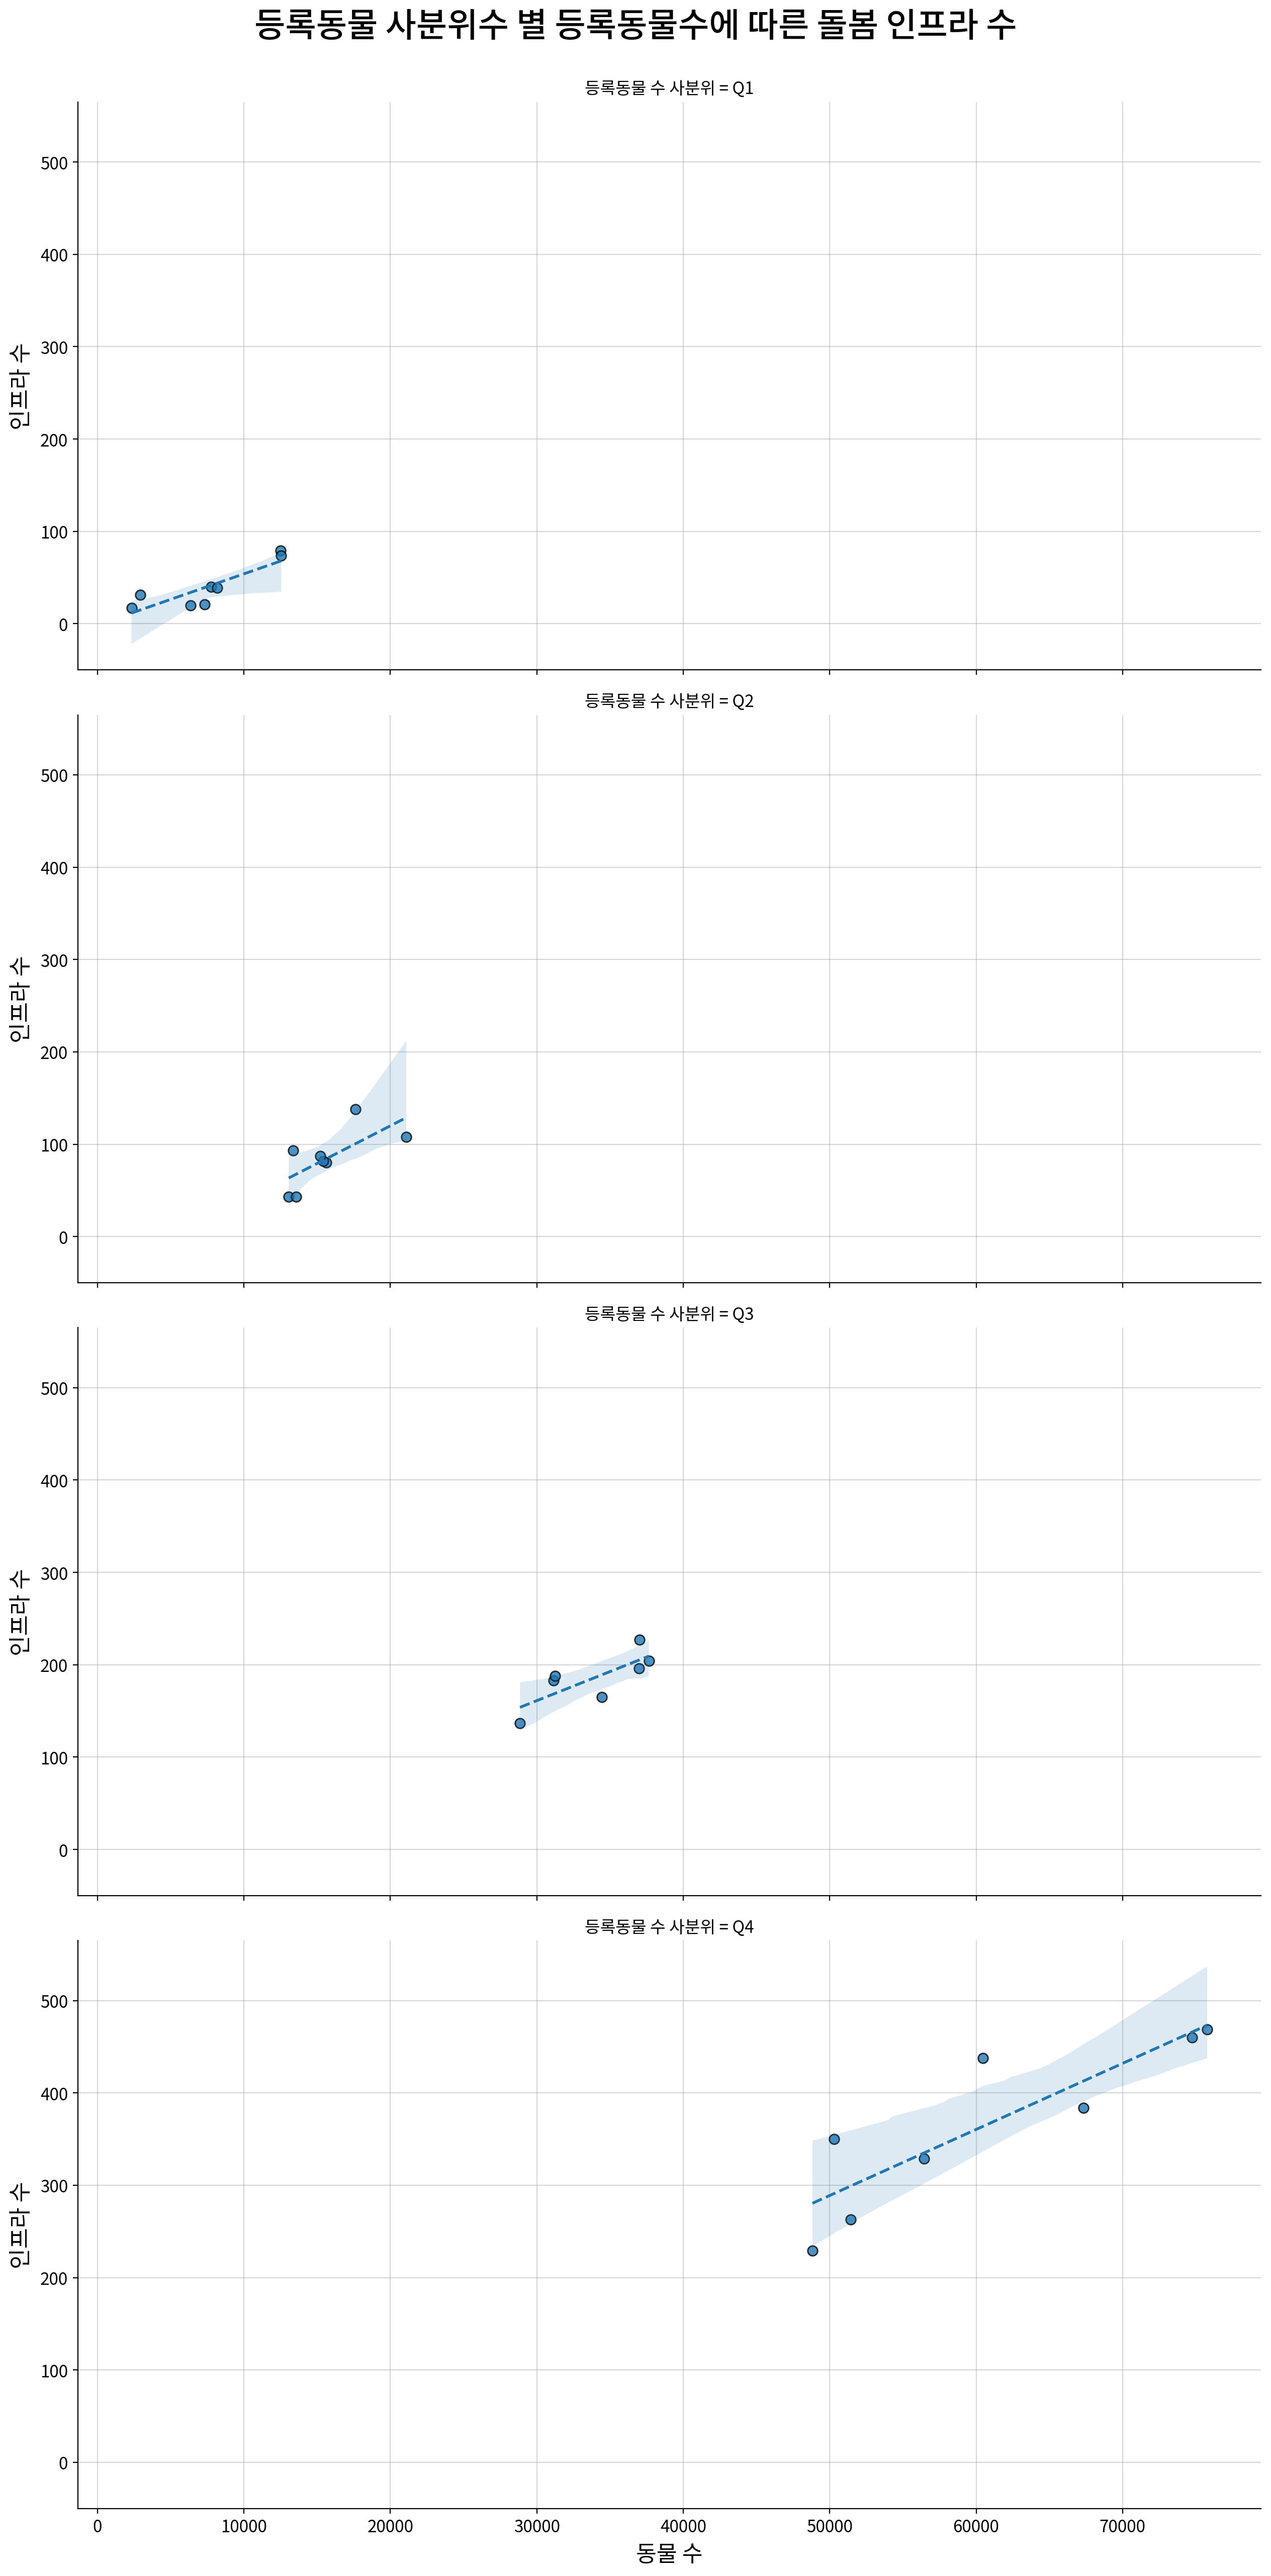

In [23]:
# 등록동물 사분위수 별 등록동물수에 따른 돌봄 인프라 수
my_plot.lmplot(data=result5, x='등록동물 수', y='인프라 수',
               title='등록동물 사분위수 별 등록동물수에 따른 돌봄 인프라 수',
               xlabel='동물 수', ylabel='인프라 수',
               palette="Set2", row="등록동물 수 사분위",
               scatter_edgecolor="#000000", scatter_linewidths=1, scatter_size=50,
               linestyle="--", linewidth=2)

In [24]:
# 평균낸건데 값이 이상함. 
result5.groupby('등록동물 수 사분위')[['등록동물 수', '인프라 수', '동물/인프라']].mean()

,등록동물 수,인프라 수,동물/인프라
등록동물 수 사분위,,,
Q1,7492.875000,40.125000,203.774046
Q2,15617.375000,84.250000,205.509284
Q3,33901.428571,185.714286,184.558769
Q4,60667.625000,365.250000,170.195052


In [25]:
q1 = result5[result5['등록동물 수 사분위'] == 'Q1']
q2 = result5[result5['등록동물 수 사분위'] == 'Q2']
q3 = result5[result5['등록동물 수 사분위'] == 'Q3']
q4 = result5[result5['등록동물 수 사분위'] == 'Q4']

In [26]:
display(q1)
display(q2)
display(q3)
display(q4)

,시_주소,등록동물 수,인프라 수,동물/인프라,등록동물 수 사분위
0,가평군,6361,20.0,318.050000,Q1
2,과천시,2941,31.0,94.870968,Q1
5,구리시,12489,79.0,158.088608,Q1
9,동두천시,7324,21.0,348.761905,Q1
15,안성시,12551,74.0,169.608108,Q1
19,여주시,7765,40.0,194.125000,Q1
20,연천군,2325,17.0,136.764706,Q1
23,의왕시,8187,39.0,209.923077,Q1


,시_주소,등록동물 수,인프라 수,동물/인프라,등록동물 수 사분위
3,광명시,21091,108.0,195.287037,Q2
6,군포시,15610,80.0,195.125000,Q2
17,양주시,15405,82.0,187.865854,Q2
18,양평군,13064,43.0,303.813953,Q2
21,오산시,15206,87.0,174.781609,Q2
25,이천시,13368,93.0,143.741935,Q2
28,포천시,13580,43.0,315.813953,Q2
29,하남시,17615,138.0,127.644928,Q2


,시_주소,등록동물 수,인프라 수,동물/인프라,등록동물 수 사분위
4,광주시,28852,137.0,210.598540,Q3
7,김포시,31128,183.0,170.098361,Q3
13,시흥시,36969,196.0,188.617347,Q3
16,안양시,37024,227.0,163.101322,Q3
24,의정부시,31233,188.0,166.132979,Q3
26,파주시,34447,165.0,208.769697,Q3
27,평택시,37657,204.0,184.593137,Q3


,시_주소,등록동물 수,인프라 수,동물/인프라,등록동물 수 사분위
1,고양시,74752,460.0,162.504348,Q4
8,남양주시,51450,263.0,195.627376,Q4
10,부천시,56443,329.0,171.559271,Q4
11,성남시,60467,438.0,138.052511,Q4
12,수원시,75775,469.0,161.567164,Q4
14,안산시,48821,229.0,213.192140,Q4
22,용인시,67345,384.0,175.377604,Q4
30,화성시,50288,350.0,143.680000,Q4


In [27]:
display(my_qtcheck.numerical_summary(data=q1).T)
display(my_qtcheck.numerical_summary(data=q2).T)
display(my_qtcheck.numerical_summary(data=q3).T)
display(my_qtcheck.numerical_summary(data=q4).T)

,등록동물 수,인프라 수,동물/인프라
count,8.0,8.0,8.0
mean,7492.875,40.125,203.774046
std,3776.580329,24.050171,87.681233
min,2325.0,17.0,94.870968
25%,5506.0,20.75,152.757632
50%,7544.5,35.0,181.866554
75%,9262.5,48.5,236.954808
max,12551.0,79.0,348.761905
rel_diff,0.006843,0.146429,0.120459
rdiff_flag,similar,diff,diff


,등록동물 수,인프라 수,동물/인프라
count,8.0,8.0,8.0
mean,15617.375,84.25,205.509284
std,2669.825352,31.540224,68.844338
min,13064.0,43.0,127.644928
25%,13527.0,70.75,167.021691
50%,15305.5,84.5,191.495427
75%,16111.25,96.75,222.418766
max,21091.0,138.0,315.813953
rel_diff,0.020377,0.002959,0.073181
rdiff_flag,similar,similar,similar


,등록동물 수,인프라 수,동물/인프라
count,7.0,7.0,7.0
mean,33901.428571,185.714286,184.558769
std,3508.83546,28.750155,19.535212
min,28852.0,137.0,163.101322
25%,31180.5,174.0,168.11567
50%,34447.0,188.0,184.593137
75%,36996.5,200.0,198.693522
max,37657.0,227.0,210.59854
rel_diff,0.015838,0.012158,0.000186
rdiff_flag,similar,similar,similar


,등록동물 수,인프라 수,동물/인프라
count,8.0,8.0,8.0
mean,60667.625,365.25,170.195052
std,10837.245247,89.403979,25.054372
min,48821.0,229.0,138.052511
25%,51159.5,312.5,157.095373
50%,58455.0,367.0,167.031809
75%,69196.75,443.5,180.440047
max,75775.0,469.0,213.19214
rel_diff,0.037852,0.004768,0.018938
rdiff_flag,similar,similar,similar


In [28]:
result4['동물수/인프라수']=result4['등록동물 수']/result4['인프라 수']
result4.head()
result6=result4.copy()

In [29]:
# 사분위수 컬럼 추가
result6['동물/인프라 사분위'] = pd.qcut(
    result4['동물수/인프라수'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4'])
result6.head()

,시_주소,등록동물 수,인프라 수,동물수/인프라수,동물/인프라 사분위
0,가평군,6361,20.0,318.050000,Q4
1,고양시,74752,460.0,162.504348,Q2
2,과천시,2941,31.0,94.870968,Q1
3,광명시,21091,108.0,195.287037,Q3
4,광주시,28852,137.0,210.598540,Q4


In [30]:
result6.groupby('동물/인프라 사분위')[['등록동물 수', '인프라 수']].mean()

,등록동물 수,인프라 수
동물/인프라 사분위,,
Q1,29408.500000,201.875
Q2,40710.250000,241.500
Q3,26563.857143,139.000
Q4,20079.500000,87.125


In [31]:
q01 = result6[result6['동물/인프라 사분위'] == 'Q1']
q02 = result6[result6['동물/인프라 사분위'] == 'Q2']
q03 = result6[result6['동물/인프라 사분위'] == 'Q3']
q04 = result6[result6['동물/인프라 사분위'] == 'Q4']

In [32]:
display(my_qtcheck.numerical_summary(data=q01).T)
display(my_qtcheck.numerical_summary(data=q02).T)
display(my_qtcheck.numerical_summary(data=q03).T)
display(my_qtcheck.numerical_summary(data=q04).T)

,등록동물 수,인프라 수,동물수/인프라수
count,8.0,8.0,8.0
mean,29408.5,201.875,138.051352
std,28453.306501,186.494303,20.677953
min,2325.0,17.0,94.870968
25%,10102.0,67.0,134.484761
50%,15491.5,115.5,140.866256
75%,52832.75,372.0,147.328604
max,75775.0,469.0,161.567164
rel_diff,0.898364,0.747835,0.019983
rdiff_flag,large_diff,large_diff,similar


,등록동물 수,인프라 수,동물수/인프라수
count,8.0,8.0,8.0
mean,40710.25,241.5,169.14545
std,23159.09702,138.422748,4.888257
min,12551.0,74.0,162.504348
25%,27147.5,159.0,165.375064
50%,34128.5,207.5,169.853234
75%,59168.5,342.75,172.364855
max,74752.0,460.0,175.377604
rel_diff,0.192852,0.163855,0.004167
rdiff_flag,diff,diff,similar


,등록동물 수,인프라 수,동물수/인프라수
count,7.0,7.0,7.0
mean,26563.857143,139.0,191.605822
std,15697.670723,81.997967,4.482395
min,7765.0,40.0,184.593137
25%,15507.5,81.0,188.2416
50%,21091.0,108.0,194.125
75%,37313.0,200.0,195.206019
max,51450.0,263.0,195.627376
rel_diff,0.259488,0.287037,0.012977
rdiff_flag,diff,diff,similar


,등록동물 수,인프라 수,동물수/인프라수
count,8.0,8.0,8.0
mean,20079.5,87.125,266.115408
std,15552.895706,79.073993,60.648725
min,6361.0,20.0,208.769697
25%,7971.25,34.5,210.429674
50%,13322.0,43.0,258.503047
75%,30250.75,144.0,316.372965
max,48821.0,229.0,348.761905
rel_diff,0.507244,1.026163,0.029448
rdiff_flag,large_diff,large_diff,similar


In [34]:
q04

,시_주소,등록동물 수,인프라 수,동물수/인프라수,동물/인프라 사분위
0,가평군,6361,20.0,318.050000,Q4
4,광주시,28852,137.0,210.598540,Q4
9,동두천시,7324,21.0,348.761905,Q4
14,안산시,48821,229.0,213.192140,Q4
18,양평군,13064,43.0,303.813953,Q4
23,의왕시,8187,39.0,209.923077,Q4
26,파주시,34447,165.0,208.769697,Q4
28,포천시,13580,43.0,315.813953,Q4
